In [3]:
import pandas as pd
import plotly.express as px
import numpy as np

df = pd.read_csv('airbnb_london.csv')

print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))


p95 = df['price'].quantile(0.95)

df_cap = df[df['price'] <= p95]

print(f"95th percentile price: £{p95:.0f}")

print(
    df_cap.groupby('room_type')['price']
    .describe()
    .round(1)
)

Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  
95th percentile price: £373
                  count   mean   std   min    25%    50%    75%    max
room_

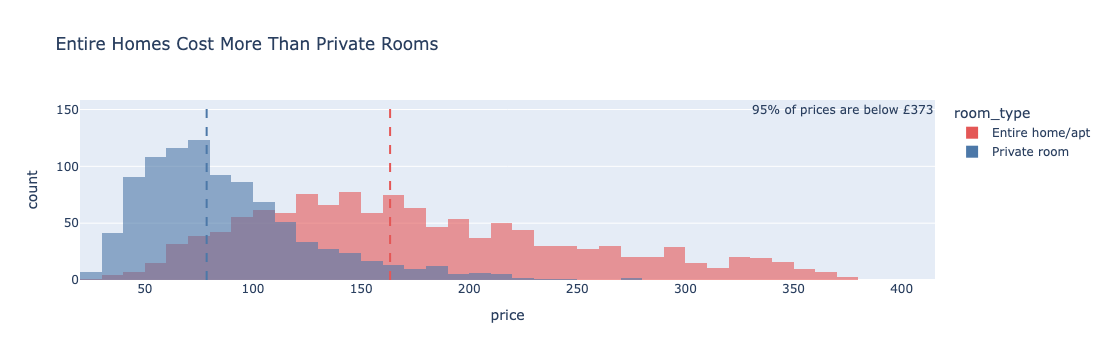

In [6]:
# Task 1 — Histogram

df_hist = df_cap[
    df_cap['room_type'].isin(['Entire home/apt', 'Private room'])
]

m1 = df_hist[df_hist['room_type'] == 'Entire home/apt']['price'].median()
m2 = df_hist[df_hist['room_type'] == 'Private room']['price'].median()


fig = px.histogram(
    df_hist,
    x='price',
    color='room_type',
    barmode='overlay',
    opacity=0.6,
    title='Entire Homes Cost More Than Private Rooms',
    color_discrete_map={
        'Entire home/apt': '#E45756',
        'Private room': '#4C78A8'
    }
)


fig.add_vline(x=m1, line_dash='dash', line_color='#E45756')
fig.add_vline(x=m2, line_dash='dash', line_color='#4C78A8')


fig.add_annotation(
    x=p95,
    y=150,
    text=f'95% of prices are below £{p95:.0f}',
    showarrow=False
)

fig.show()

In [10]:
print(df.columns)

Index(['neighbourhood', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'availability_365', 'reviews_per_month'],
      dtype='object')


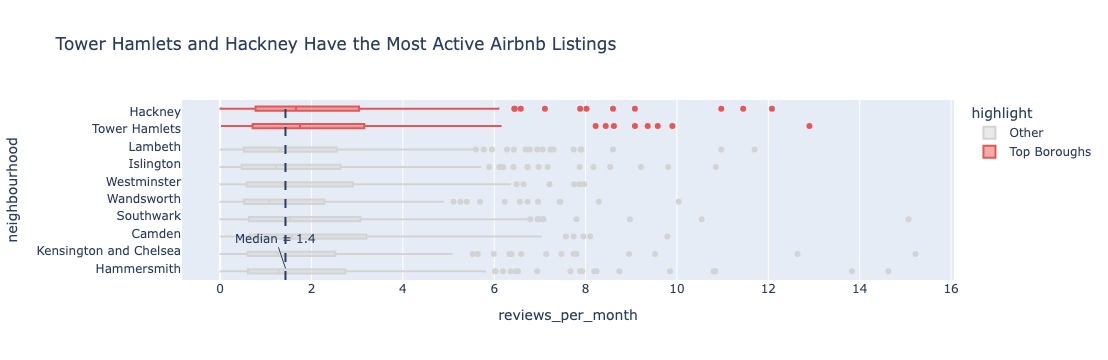

In [12]:
# Task 2 — Box Plot

df_box = df[df['reviews_per_month'] > 0].copy()

top2 = (
    df_box.groupby('neighbourhood')['reviews_per_month']
    .median()
    .sort_values(ascending=False)
    .head(2)
    .index
)

df_box['highlight'] = df_box['neighbourhood'].apply(
    lambda x: 'Top Boroughs' if x in top2 else 'Other'
)

fig = px.box(
    df_box,
    x='reviews_per_month',
    y='neighbourhood',
    color='highlight',
    orientation='h',
    points='outliers',
    
    title=f'{top2[0]} and {top2[1]} Have the Most Active Airbnb Listings',

    color_discrete_map={
        'Top Boroughs': '#E45756',
        'Other': 'lightgrey'
    }
)

median_reviews = df_box['reviews_per_month'].median()

fig.add_vline(
    x=median_reviews,
    line_dash='dash'
)

fig.add_annotation(
    x=median_reviews,
    y=0,
    text=f'Median = {median_reviews:.1f}',
    showarrow=True
)

fig.show()